# Meridional heat transport and vertical diffusivity: Figure 5

Last modified May 5 2025

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4

In [2]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
            'p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
            'CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


In [3]:
# import data loading function
# import sys
# if '/tigress/wenchang/wython' not in sys.path:
#     sys.path.append('/tigress/wenchang/wython')
    
# from misc.modelout import get_modelout_data, get_modelout_files

import sys
if '/tigress/wenchang/wython/' not in sys.path:
    sys.path.append('/tigress/wenchang/wython/')
    
from modelout.modelout import get_modelout_data, get_modelout_files

# load MHT data

In [4]:
# load Pacific meridional heat transport in both models for -4% and -6% Solar experiments

lat = 40

# FLOR_Amht_m4 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_FLOR_m4p0sol_CTL1860.0101-1187.nc')
# FLOR_Amht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_FLOR_m6p0sol_CTL1860.0101-0597.nc')
FLOR_Pmht_m4 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_FLOR_m4p0sol_CTL1860.0101-1187.nc')
FLOR_Pmht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_FLOR_m6p0sol_CTL1860.0101-0597.nc')

# CM21_Amht_m4 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc')
# CM21_Amht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_CM2.1p1_CTL1860_m6pctSolar.0101-1293.nc')
CM21_Pmht_m4 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc')
CM21_Pmht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_CM2.1p1_CTL1860_m6pctSolar.0101-1293.nc')

# shift the start year from 101 to zero
def shift_year(q):
    q = q.assign_coords(year=q.year - q.year.min())
    return q

FLOR_Pmht_m4 = shift_year(FLOR_Pmht_m4)
FLOR_Pmht_m6 = shift_year(FLOR_Pmht_m6)
CM21_Pmht_m4 = shift_year(CM21_Pmht_m4)
CM21_Pmht_m6 = shift_year(CM21_Pmht_m6)


In [5]:
def plot_MHT_pacific(ax):
    # input one axis

    #plt.style.use('../func/paper.mplstyle')
    
    linestyle = ['--','-']
    
    # Pacific mht

    (CM21_Pmht_m4*1e-15).rolling(year=10,center=True).mean('year').plot(ax=ax,color='b', label='CM2.1 -4%',
                                                                linestyle=linestyle[1])
    (CM21_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').plot(ax=ax,color='darkblue', label='CM2.1 -6%',
                                                                linestyle=linestyle[1])
    
    (FLOR_Pmht_m4*1e-15).rolling(year=10,center=True).mean('year').plot(ax=ax,color='b',label='FLOR -4%',
                                                               linestyle = linestyle[0])
    (FLOR_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').plot(ax=ax,color='darkblue',label='FLOR -6%',
                                                               linestyle = linestyle[0])
    
    
    #ax.set_title('Indo-Pacific')
    
    # plot stars for experiments that crashed
    IP_crash_x = [(FLOR_Pmht_m4*1e-15).rolling(year=10,center=True).mean('year').dropna('year').year.max(),
                  (FLOR_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').dropna('year').year.max(),
                  (CM21_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').dropna('year').year.max(),
                 933] # plot the first crash in CM2.1 -6%
    IP_crash_y = [(FLOR_Pmht_m4*1e-15).rolling(year=10,center=True).mean('year').dropna('year').isel(year=-1),
                  (FLOR_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').dropna('year').isel(year=-1),
                  (CM21_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').dropna('year').isel(year=-1),
                 (CM21_Pmht_m6*1e-15).rolling(year=10,center=True).mean('year').dropna('year').isel(year=933)]
    ax.scatter(IP_crash_x, IP_crash_y, color='r', marker='x', s=100,zorder=10)
    
    for ii in range(1):
        ax.legend(fontsize=15)
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.grid(linestyle='--')
        ax.set_xlim(0,1900)
        #ax.set_xticks(np.arange(100,2100,100))
        #ax[ii].set_ylim(-5,50)
        ax.axhline(0,color='k',linewidth=1)
        
    ax.set_xlabel('Years')
    ax.set_ylabel('[PW]')
    
    if lat >= 0:
        ax.set_title(f'Pacific meridional heat transport across {lat}N (10-year running mean)')
    else:
        ax.set_title(f'Indo-Pacific meridional heat transport across {-lat}S (10-year running mean)')

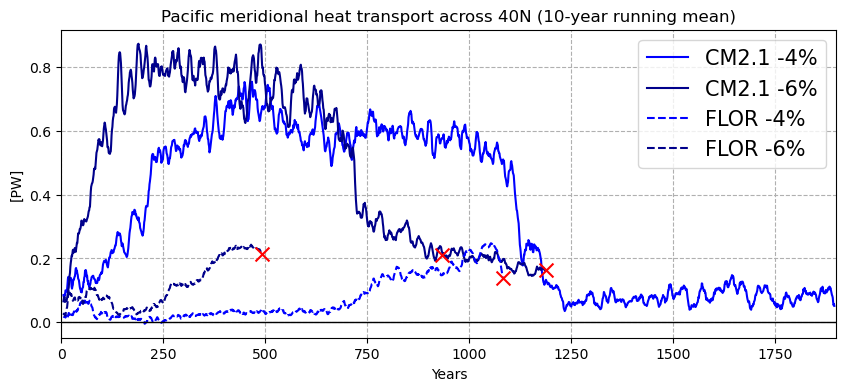

In [6]:
fig, ax = plt.subplots(1,1,figsize=(10,4),sharex=False, sharey=True)
plot_MHT_pacific(ax)

# Plot maps

In [7]:
# plot maps
# /tigress/mvchung/ANALYSIS/Solar_NEW/import_plot_NPacific_diffusivity_topography_wind.ipynb

In [8]:
# # load data: first 50 years of vertical diffusivity
# CM21 = xr.open_dataarray('./MODEL_OUT/diff_cbt_t_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0150_output.nc')
# FLOR = xr.open_dataarray('./MODEL_OUT/diff_cbt_t_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0150_output.nc')


In [9]:
# get difference between first 5 and last 5 years
def last10_minus_first10_JFM(da):
    da_first = da.sel(st_ocean=slice(50,2000)).mean('st_ocean').isel(time=slice(0,10*12)).groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')
    da_last = da.sel(st_ocean=slice(50,2000)).mean('st_ocean').isel(time=slice(-10*12,None)).groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')

    diff = da_last - da_first
    return diff

In [10]:
# %time
# CM21_diff = last10_minus_first10_JFM(CM21)
# FLOR_diff = last10_minus_first10_JFM(FLOR)

In [11]:
# # save to processed_data
# CM21_diff.to_netcdf('./processed_data/diff_cbt_t_141-150_minus_101-110_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE.nc')
# FLOR_diff.to_netcdf('./processed_data/diff_cbt_t_141-150_minus_101-110_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE.nc')

In [12]:
CM21_diff = xr.open_dataarray('./processed_data/diff_cbt_t_141-150_minus_101-110_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE.nc')
FLOR_diff = xr.open_dataarray('./processed_data/diff_cbt_t_141-150_minus_101-110_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE.nc')

In [13]:
def plot_map(ax,da,modelname, 
             lat1, lat2, lon1, lon2):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    
    # Define the projection with central longitude set to -180
    #proj = ccrs.PlateCarree(central_longitude=-180)
    
    # Create the figure and axis with the Cartopy projection
    #fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(4,4))
    
    # Plot the data
    p = da.plot(
        ax=ax, 
        transform=ccrs.PlateCarree(),  # Specify the data's coordinate reference system
        vmin=-2, vmax=2, cmap='RdBu_r', 
        add_colorbar=False, rasterized=True
        # cbar_kwargs={
        #     'label': 'm^2/s',
        #     'extend': 'both',
        #     'shrink': 0.7 # Extend the colorbar in both directions
        # }
    )
    
    # Add features to the map
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightgray')
    
    # Set the extent of the map (longitude and latitude bounds)
    ax.set_extent([-220, -110, 0, 70], crs=ccrs.PlateCarree())
    
    # Add a title
    #ax.set_title(f'JFM diffusivity change\nyrs 40-50 minus 0-10')
    
    # Add 'CM2.1' in bold, large font in the upper left corner
    ax.text(
        -215, 15,  # Upper-left corner (adjust coordinates as necessary)
        modelname, 
        fontsize=20,  # Large font size
        fontweight='bold',  # Bold text
        transform=ccrs.PlateCarree()  # Use the same projection as the data
    )
    
    # Plot the box
    #lat1, lat2 = 40, 55#40, 55
    #lon1, lon2 = -190, -140#-170, -130
    ax.plot(
        [lon1, lon2, lon2, lon1, lon1],  # Longitude bounds (close the rectangle)
        [lat1, lat1, lat2, lat2, lat1],  # Latitude bounds (close the rectangle)
        color='black', linewidth=2, transform=ccrs.PlateCarree()
    )
    
    #plt.show()

    return p


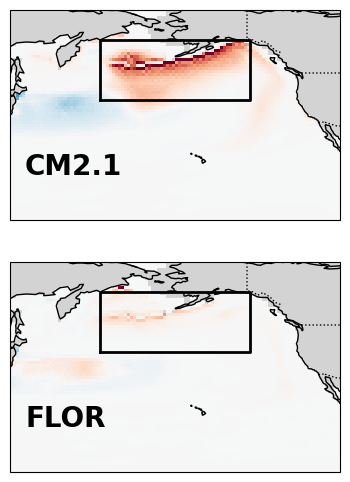

In [14]:
import cartopy.crs as ccrs
fig, ax = plt.subplots(2,1,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-180)}, figsize=(8,6))
plot_map(ax[0],CM21_diff,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140)  # First map
plot_map(ax[1],FLOR_diff,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140)  # Second map

## plot with ice edge

In [15]:
def plot_contours_icemonth_years(da, ax,
                             firstyear=-50, lastyear=None,
                                color='k'):
    t_temp = da.year.isel(year=slice(firstyear,lastyear))
    y0, y1 = t_temp.min(), t_temp.max()

    ctr = da.isel(year=slice(firstyear,lastyear)).mean('year').plot.contour(ax=ax,levels=[1],
                                                                      x='xt',colors=color,zorder=1, transform=ccrs.PlateCarree())
    
    ax.set_title(f'')
    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_facecolor('gray')
    
    return ctr

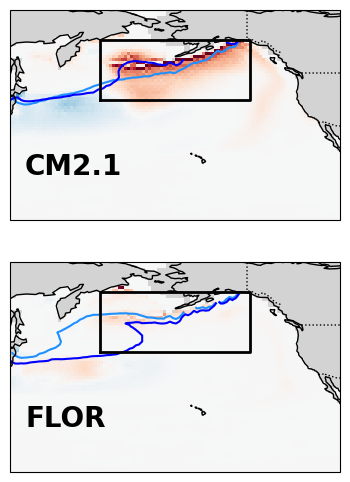

In [16]:
# import ice

fig, ax = plt.subplots(2,1,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-180)}, figsize=(8,6))
plot_map(ax[0],CM21_diff,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140)  # First map
plot_map(ax[1],FLOR_diff,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140)  # Second map

CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')

plot_contours_icemonth_years(CM21_m6_ice_months, ax[0], color='dodgerblue',
                                       firstyear=0, lastyear=10)
plot_contours_icemonth_years(CM21_m6_ice_months, ax[0], color='b',
                                       firstyear=40, lastyear=50)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax[1], color='dodgerblue',
                                       firstyear=0, lastyear=10)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax[1], color='b',
                                       firstyear=40, lastyear=50)

# select a box and make the Hovmollers in that box, draw on maps

In [17]:
def plot_hovmoller(fig, ax, CM21, FLOR,
                  levels1 = np.arange(0,1.1,0.1),
                  depth1=1000,depth2=0):
    # input 2 axes
    #fig, ax = plt.subplots(2,1,figsize=(12,7),sharex=True,sharey=True)

    t = np.arange(0,100,1/12)
    # if CM21.time.dtype == 'float64':
    #     t = CM21.time
    # else:
    #     t = np.arange(int(CM21.time.min().dt.year),
    #                   int(CM21.time.max().dt.year)+1, 
    #                   1/12)       
    d = FLOR.st_ocean
    
    cf0 = ax[0].contourf(t,d,CM21.transpose(),levels=levels1,extend='both')
    
    cf1 = ax[1].contourf(t,d,FLOR.transpose(),levels=levels1,extend='both')
     
    #ax[0].set_title('CM2.1 (ensemble mean) total vertical diffusivity')
    #ax[1].set_title('FLOR total vertical diffusivity')

    for axis in ax:
        axis.grid(True,linestyle='--',zorder=10)
        # Ensure the grid is above the contourf plot
        axis.set_axisbelow(False)
        axis.set_ylim(depth1,depth2)
    
    # colorbars
    #fig.colorbar(cf1,ax=ax,label=FLOR_m6.units,shrink=0.7)
    
    #fig.suptitle(f'{FLOR_m6.long_name} -6% Solar')
    ax[1].set_xlabel('Years')
    ax[0].set_ylabel('Depth [m]')
    ax[1].set_ylabel('Depth [m]')

    # plot model names
    ax[0].text(105, 1800, 'CM2.1', 
               color='white', fontsize=20, fontweight='bold')
    ax[1].text(105, 1800, 'FLOR', 
               color='white', fontsize=20, fontweight='bold')

    return cf0

In [18]:
# load data: first 50 years of vertical diffusivity
CM21 = xr.open_dataarray('./MODEL_OUT/NPacific/diff_cbt_t_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_output.nc')
FLOR = xr.open_dataarray('./MODEL_OUT/NPacific/diff_cbt_t_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_output.nc')


In [31]:
def get_box_avg(da, lat1=40, lat2=60, lon1=-190, lon2=-140):
    da_new = da.sel(xt_ocean=slice(lon1,lon2),
                    yt_ocean = slice(lat1, lat2)).mean(('xt_ocean','yt_ocean'))
    return da_new

CM21_box = get_box_avg(CM21)
FLOR_box = get_box_avg(FLOR)

### save files

In [32]:
CM21_box.to_netcdf('./processed_data/diff_cbt_t_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific_box.nc')
FLOR_box.to_netcdf('./processed_data/diff_cbt_t_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_output_NPacific_box.nc')

# Function for JFM mean 

In [30]:
# Get JFM mean
def JFM_mean(da):
    da_JFM_mean = da.groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')
    return da_JFM_mean

# Plot Figure 5

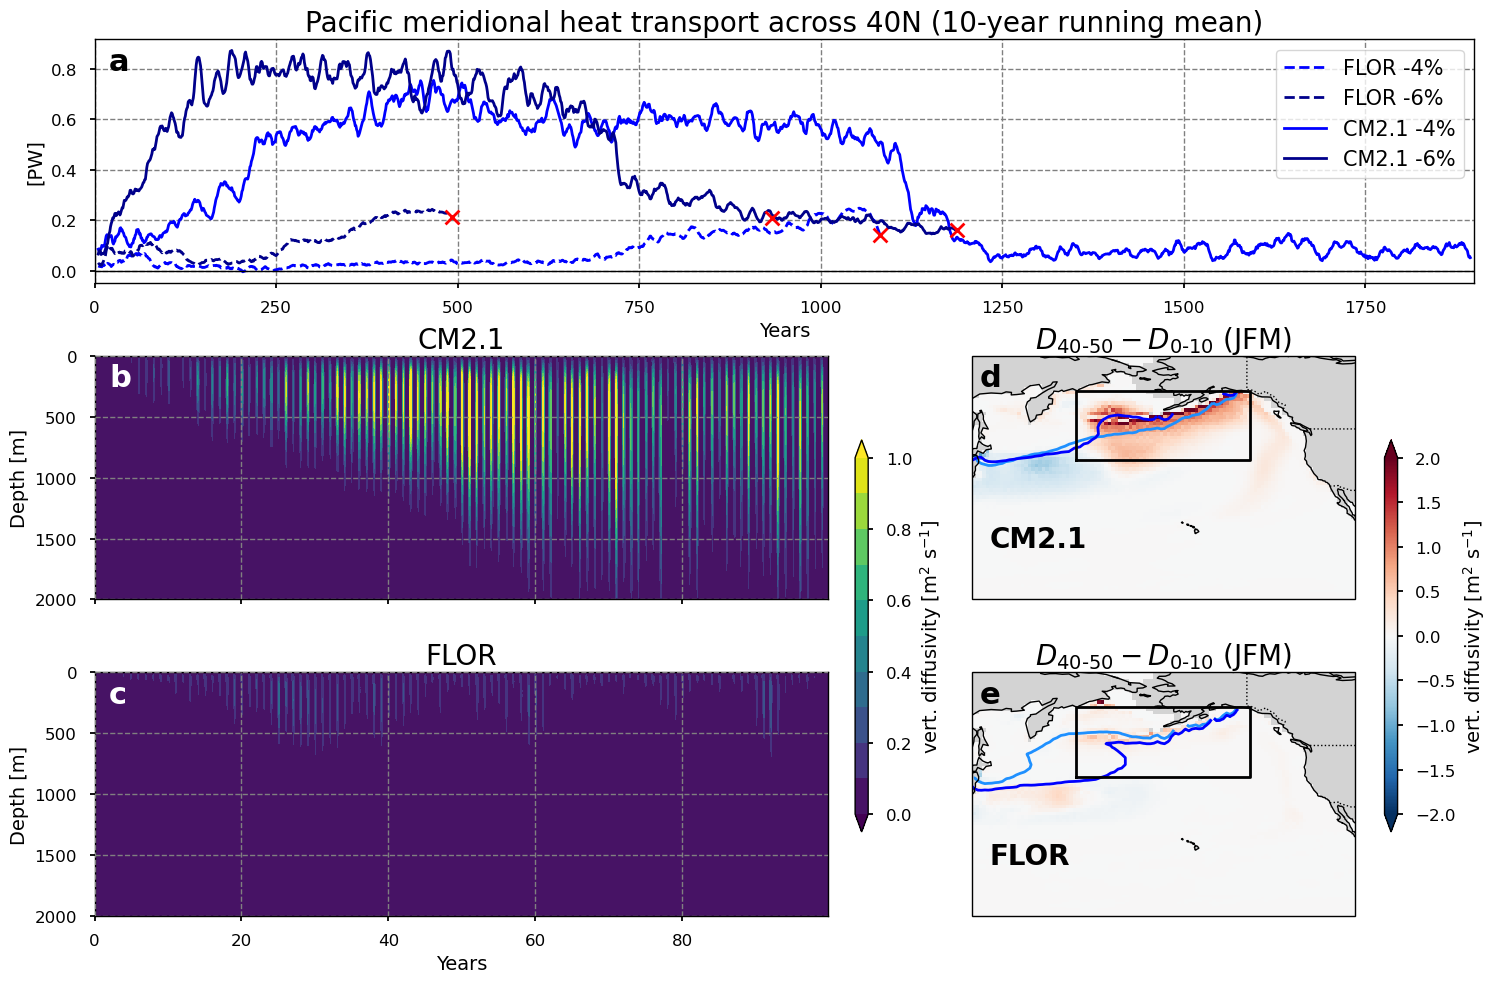

In [73]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.style.use('../func/paper.mplstyle')

fig = plt.figure(figsize=(15, 10), constrained_layout=False)  
gs = gridspec.GridSpec(3, 2, height_ratios=[1,1,1], width_ratios=[1.5, 1])

# Top timeseries plot spanning the full width
ax0 = fig.add_subplot(gs[0, :])

# Bottom row: Hovmöller on the left (wider), maps stacked on the right
ax1 = fig.add_subplot(gs[1, 0])  # Hovmöller (wide)
ax3 = fig.add_subplot(gs[2, 0])  # Hovmöller (wide) sharing x and y

ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=-180))  # Top map
ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=-180))  # Bottom map

# Plot MHT
plot_MHT_pacific(ax0)

# plot hovmoller
cf = plot_hovmoller(fig, [ax1, ax3], CM21_box, FLOR_box, depth1=2000, depth2=0)
ax1.set_title('CM2.1')
ax3.set_title('FLOR')

# plot maps of diffusivity difference, years 40-50 minus 0-10
p = plot_map(ax2,CM21_diff,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140)  # First map
plot_map(ax4,FLOR_diff,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140)  # Second map
# plot ice edge on maps
CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')
plot_contours_icemonth_years(CM21_m6_ice_months, ax2, color='dodgerblue', firstyear=0, lastyear=10)
plot_contours_icemonth_years(CM21_m6_ice_months, ax2, color='b', firstyear=40, lastyear=50)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax4, color='dodgerblue', firstyear=0, lastyear=10)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax4, color='b', firstyear=40, lastyear=50)

ax2.set_title(r"$D_{40\text{-}50} - D_{0\text{-}10}$ (JFM)")
ax4.set_title(r"$D_{40\text{-}50} - D_{0\text{-}10}$ (JFM)")

ax1.tick_params(labelbottom=False)

plt.tight_layout()

plt.subplots_adjust(hspace=0.3, wspace=-0.15)

#colorbars
# hovmoller
cbar = fig.colorbar(cf,ax=[ax1, ax3],
                    label=r'vert. diffusivity [m$^2$ s$^{-1}$]',
                    shrink=0.7,aspect=30,orientation='vertical',pad=0.03)
# maps
map_cbar = fig.colorbar(p,ax=[ax2, ax4],
                        label=r'vert. diffusivity [m$^2$ s$^{-1}$]',
                        shrink=0.7,aspect=30,orientation='vertical',pad=0.05, extend='both')

# Label axes with letters
import string
axes = [ax0, ax1, ax3, ax2, ax4]
colors = ['k','w','w','k','k']
xpos = [0.01, 0.02, 0.02, 0.02, 0.02]
for i, ax in enumerate(axes):
    ax.text(xpos[i], 0.97, f"{string.ascii_lowercase[i]}",
            transform=ax.transAxes,
            color=colors[i],
            fontsize=22, fontweight="bold",
            va="top", ha="left")

#plt.savefig("Figure5.pdf", bbox_inches='tight', dpi=300)  # Prevents clipping

# Add indicators for time periods

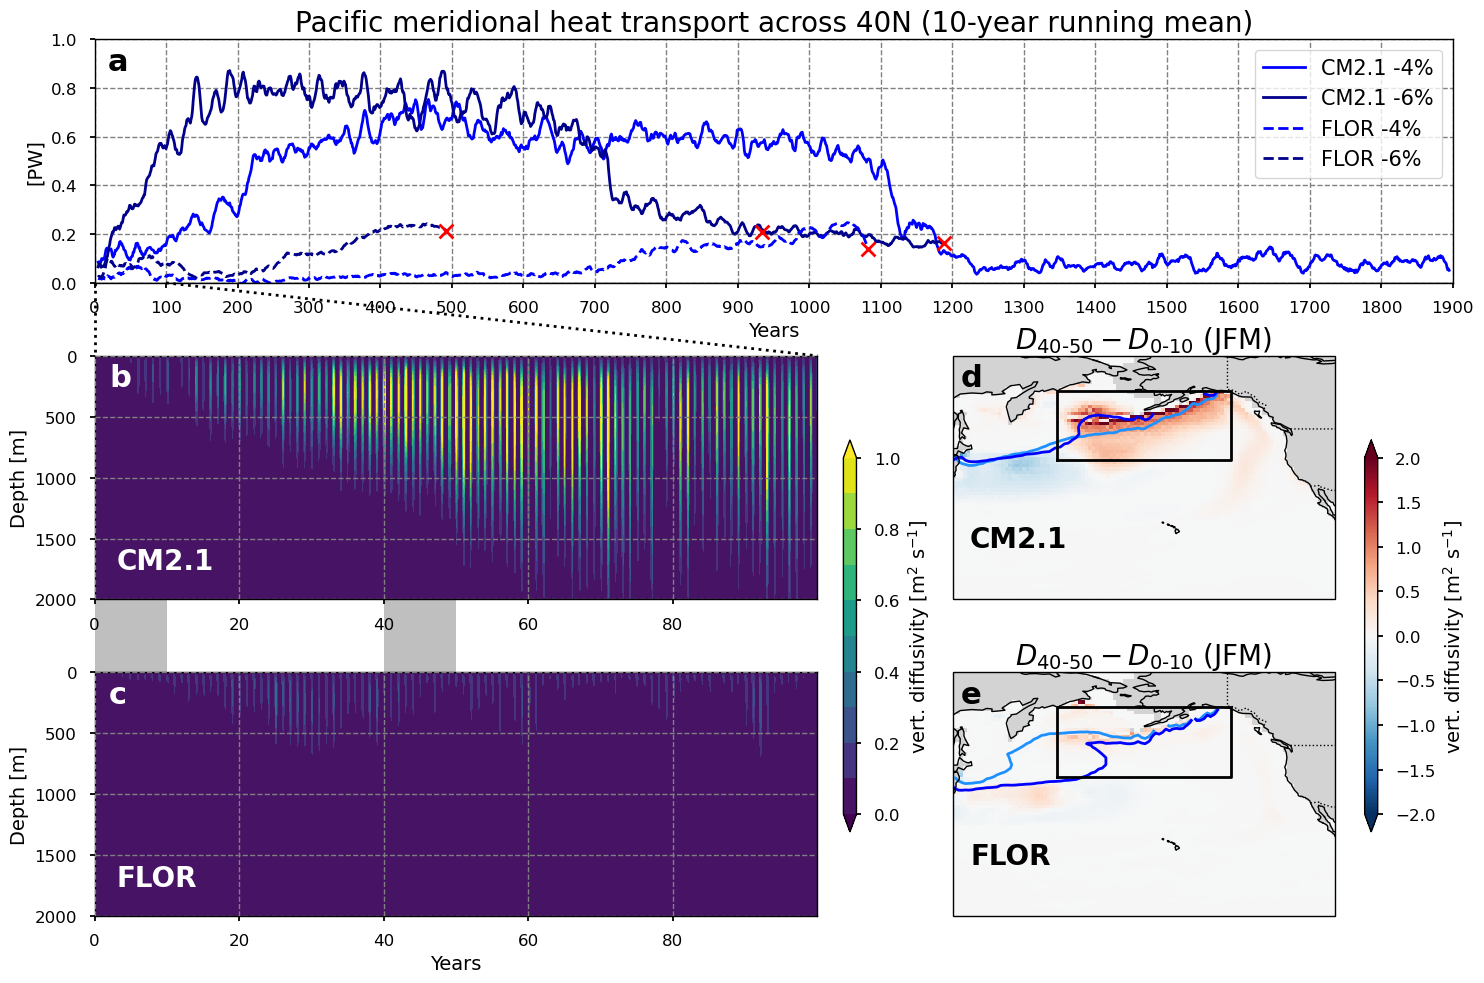

In [107]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.style.use('../func/paper.mplstyle')

fig = plt.figure(figsize=(15, 10), constrained_layout=False)  
gs = gridspec.GridSpec(3, 2, height_ratios=[1,1,1], width_ratios=[1.5, 1])

# Top timeseries plot spanning the full width
ax0 = fig.add_subplot(gs[0, :])

# Bottom row: Hovmöller on the left (wider), maps stacked on the right
ax1 = fig.add_subplot(gs[1, 0])  # Hovmöller (wide)
ax3 = fig.add_subplot(gs[2, 0])  # Hovmöller (wide) sharing x and y

ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=-180))  # Top map
ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=-180))  # Bottom map

# Plot MHT
plot_MHT_pacific(ax0)
ax0.set_ylim(0,1)
ax0.set_xticks(np.arange(0,2000,100))

# plot hovmoller
cf = plot_hovmoller(fig, [ax1, ax3], CM21_box, FLOR_box, depth1=2000, depth2=0)
# ax1.set_title('CM2.1')
# ax3.set_title('FLOR')

# Add bold white text inside bottom-left of Hovmöller plots
ax1.text(0.03, 0.1, "CM2.1",
         transform=ax1.transAxes,
         fontsize=20, fontweight="bold",
         color="white", ha="left", va="bottom")

ax3.text(0.03, 0.1, "FLOR",
         transform=ax3.transAxes,
         fontsize=20, fontweight="bold",
         color="white", ha="left", va="bottom")

# plot maps of diffusivity difference, years 40-50 minus 0-10
p = plot_map(ax2,CM21_diff,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140)  # First map
plot_map(ax4,FLOR_diff,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140)  # Second map
# plot ice edge on maps
CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')
plot_contours_icemonth_years(CM21_m6_ice_months, ax2, color='dodgerblue', firstyear=0, lastyear=10)
plot_contours_icemonth_years(CM21_m6_ice_months, ax2, color='b', firstyear=40, lastyear=50)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax4, color='dodgerblue', firstyear=0, lastyear=10)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax4, color='b', firstyear=40, lastyear=50)

ax2.set_title(r"$D_{40\text{-}50} - D_{0\text{-}10}$ (JFM)")
ax4.set_title(r"$D_{40\text{-}50} - D_{0\text{-}10}$ (JFM)")

#ax1.tick_params(labelbottom=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=-0.15)

#colorbars
# hovmoller
cbar = fig.colorbar(cf,ax=[ax1, ax3],
                    label=r'vert. diffusivity [m$^2$ s$^{-1}$]',
                    shrink=0.7,aspect=30,orientation='vertical',pad=0.03)
# maps
map_cbar = fig.colorbar(p,ax=[ax2, ax4],
                        label=r'vert. diffusivity [m$^2$ s$^{-1}$]',
                        shrink=0.7,aspect=30,orientation='vertical',pad=0.05, extend='both')

# Label axes with letters
import string
axes = [ax0, ax1, ax3, ax2, ax4]
colors = ['k','w','w','k','k']
xpos = [0.01, 0.02, 0.02, 0.02, 0.02]
for i, ax in enumerate(axes):
    ax.text(xpos[i], 0.97, f"{string.ascii_lowercase[i]}",
            transform=ax.transAxes,
            color=colors[i],
            fontsize=22, fontweight="bold",
            va="top", ha="left")


# Convert a point in data coords of one axis to figure coords
def data_to_fig_coords(ax, x, y):
    return fig.transFigure.inverted().transform(ax.transData.transform((x, y)))
def plot_line(fig, ax0, ax1, 
              x1, y1, x2, y2,
             color='k',linestyle=":"):
    x11, y11 = data_to_fig_coords(ax0, x1, y1)
    x22, y22 = data_to_fig_coords(ax1, x2, y2)
    line = plt.Line2D([x11, x22], [y11, y22],
                       transform=fig.transFigure,
                       color=color, linestyle=linestyle)
    fig.add_artist(line)

# plot lines between timeseries and hovmoller
plot_line(fig, ax0, ax1, 0, 0, 0, 0)
plot_line(fig, ax0, ax1, 100, 0, 100, 0)

# # plot lines between hovmollers
# plot_line(fig, ax1, ax3, 0, 2000, 0, 0, color='gray', linestyle=':')
# plot_line(fig, ax1, ax3, 10, 2000, 10, 0, color='gray', linestyle=':')
# plot_line(fig, ax1, ax3, 40, 2000, 40, 0, color='gray', linestyle=':')
# plot_line(fig, ax1, ax3, 50, 2000, 50, 0, color='gray', linestyle=':')

# plot shading to indicate time periods on Hovmollers shown in maps
from matplotlib.patches import Polygon
x0_low, y0_low = data_to_fig_coords(ax3, 0, 0)
x0_high, y0_high = data_to_fig_coords(ax1, 0, 2000)
x1_high, y1_high = data_to_fig_coords(ax1, 10, 2000)
x1_low, y1_low = data_to_fig_coords(ax3, 10, 0)

# Define polygon vertices (go around the band)
poly_coords = [(x0_low, y0_low),
               (x0_high, y0_high),
               (x1_high, y1_high),
               (x1_low, y1_low)]

polygon = Polygon(poly_coords, 
                  transform=fig.transFigure,
                  facecolor='gray', alpha=0.5, zorder=0)
fig.add_artist(polygon)

x0_low, y0_low = data_to_fig_coords(ax3, 40, 0)
x0_high, y0_high = data_to_fig_coords(ax1, 40, 2000)
x1_high, y1_high = data_to_fig_coords(ax1, 50, 2000)
x1_low, y1_low = data_to_fig_coords(ax3, 50, 0)

# Define polygon vertices (go around the band)
poly_coords = [(x0_low, y0_low),
               (x0_high, y0_high),
               (x1_high, y1_high),
               (x1_low, y1_low)]

polygon = Polygon(poly_coords, 
                  transform=fig.transFigure,
                  facecolor='gray', alpha=0.5, zorder=0)
fig.add_artist(polygon)

    
plt.savefig("Figure5.pdf", bbox_inches='tight', dpi=300)  # Prevents clipping